In [1]:
import os
from glob import glob
import torch
import numpy as np
X_train = np.stack([np.loadtxt(file, dtype=np.float32) for file in glob(os.path.join("train/Inertial Signals", "*.txt"))], axis=-1)
y_train = np.loadtxt("train/y_train.txt", dtype=np.int64) - 1
X_test = np.stack([np.loadtxt(file, dtype=np.float32) for file in glob(os.path.join("test/Inertial Signals", "*.txt"))], axis=-1)
y_test = np.loadtxt("test/y_test.txt", dtype=np.int64) - 1 
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7352, 128, 9), (7352,), (2947, 128, 9), (2947,))

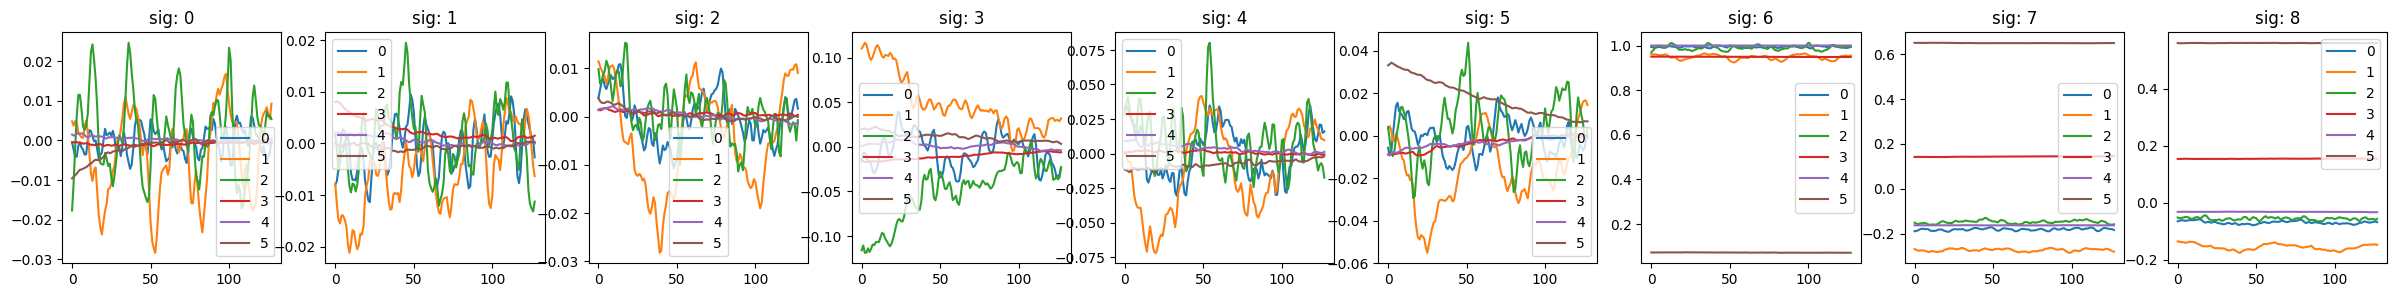

In [2]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 9, figsize=(30, 3))
for i in range(9):   
    for j in range(6):
        idx = np.where(y_train == j)[0]
        axs[i].plot(X_train[idx, :, i].mean(0), label=j)
    axs[i].set_title(f'sig: {i}')
    axs[i].legend()
plt.show()

In [3]:
y1 = (y_train == 5)
X1 = X_train
y_ = y_train[~y1]
y2 = (y_ == 3) | (y_ == 4)
X2 = X_train[~y1, :, :]
y3 = (y_[y2] > 3).astype(int)
X3 = X2[y2]
y4 = y_[~y2]
X4 = X2[~y2]
X1.shape, X2.shape, X3.shape, X4.shape

((7352, 128, 9), (5945, 128, 9), (2660, 128, 9), (3285, 128, 9))

## 学習1

In [4]:
from cv import cvTrain, cvTest
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from mytorch import CNNLSTM
RF1 = cvTrain(X1, y1, RandomForestClassifier, {})
GB1 = cvTrain(X1, y1, HistGradientBoostingClassifier, {})
linSV1 = cvTrain(X1, y1, SVC, {"kernel": "linear", "C": 1e-1, "probability": True})
SV1 = cvTrain(X1, y1, SVC, {"C": 1e-1, "probability": True})
CNN0LSTM2_1 = cvTrain(X1, y1.astype(int), CNNLSTM, {"classes": 2, "dim": 64, "num_cnn": 0, "num_lstm": 2})
CNN2LSTM1_1 = cvTrain(X1, y1.astype(int), CNNLSTM, {"classes": 2, "dim": 32, "num_cnn": 1, "num_lstm": 1})
CNN3LSTM0_1 = cvTrain(X1, y1.astype(int), CNNLSTM, {"classes": 2, "dim": 16, "num_cnn": 3, "num_lstm": 0})

Mean Accuracy: 1.0000
Mean Accuracy: 1.0000
Mean Accuracy: 1.0000
Mean Accuracy: 0.9980


Fold1:   0%|          | 0/150 [00:00<?, ?it/s]

C:\Users\Ur451\Desktop\SSM\.venv\Lib\site-packages\torch\autograd\graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


========Early Stopping: Epoch6========


Fold2:   0%|          | 0/150 [00:00<?, ?it/s]

...

========Early Stopping: Epoch12========


Fold4:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch6========


Fold5:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch6========
Mean Accuracy: 1.0000


## 学習2

In [5]:
from cv import cvTrain, cvTest
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from mytorch import CNNLSTM
RF2 = cvTrain(X2, y2, RandomForestClassifier, {})
GB2= cvTrain(X2, y2, HistGradientBoostingClassifier, {})
linSV2 = cvTrain(X2, y2, SVC, {"kernel": "linear", "C": 1e-1, "probability": True})
SV2 = cvTrain(X2, y2, SVC, {"C": 1e-1, "probability": True})
CNN0LSTM2_2 = cvTrain(X2, y2.astype(int), CNNLSTM, {"classes": 2, "dim": 64, "num_cnn": 0, "num_lstm": 2})
CNN2LSTM1_2 = cvTrain(X2, y2.astype(int), CNNLSTM, {"classes": 2, "dim": 32, "num_cnn": 1, "num_lstm": 1})
CNN3LSTM0_2 = cvTrain(X2, y2.astype(int), CNNLSTM, {"classes": 2, "dim": 16, "num_cnn": 3, "num_lstm": 0})

Mean Accuracy: 0.9983
Mean Accuracy: 0.9992
Mean Accuracy: 0.6945
Mean Accuracy: 0.9993


Fold1:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch8========


Fold2:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch11========


...

========Early Stopping: Epoch10========


Fold4:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch8========


Fold5:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch12========
Mean Accuracy: 1.0000


## 学習3

In [6]:
from cv import cvTrain, cvTest
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from mytorch import CNNLSTM
RF3 = cvTrain(X3, y3, RandomForestClassifier, {})
GB3= cvTrain(X3, y3, HistGradientBoostingClassifier, {})
linSV3 = cvTrain(X3, y3, SVC, {"kernel": "linear", "C": 1e-1, "probability": True})
SV3 = cvTrain(X3, y3, SVC, {"C": 1e-1, "probability": True})
CNN0LSTM2_3 = cvTrain(X3, y3.astype(int), CNNLSTM, {"classes": 2, "dim": 64, "num_cnn": 0, "num_lstm": 2})
CNN2LSTM1_3 = cvTrain(X3, y3.astype(int), CNNLSTM, {"classes": 2, "dim": 32, "num_cnn": 1, "num_lstm": 1})
CNN3LSTM0_3 = cvTrain(X3, y3.astype(int), CNNLSTM, {"classes": 2, "dim": 16, "num_cnn": 3, "num_lstm": 0})

Mean Accuracy: 0.9436
Mean Accuracy: 0.9447
Mean Accuracy: 0.8628
Mean Accuracy: 0.8523


Fold1:   0%|          | 0/150 [00:00<?, ?it/s]

Fold2:   0%|          | 0/150 [00:00<?, ?it/s]

Fold3:   0%|          | 0/150 [00:00<?, ?it/s]

Fold4:   0%|          | 0/150 [00:00<?, ?it/s]

...

Fold3:   0%|          | 0/150 [00:00<?, ?it/s]

Fold4:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch58========


Fold5:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch115========
Mean Accuracy: 0.9560


## 学習4

In [7]:
from cv import cvTrain, cvTest
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from mytorch import CNNLSTM
RF4 = cvTrain(X4, y4, RandomForestClassifier, {})
GB4= cvTrain(X4, y4, HistGradientBoostingClassifier, {})
linSV4 = cvTrain(X4, y4, SVC, {"kernel": "linear", "C": 1e-1, "probability": True})
SV4 = cvTrain(X4, y4, SVC, {"C": 1e-1, "probability": True})
CNN0LSTM2_4 = cvTrain(X4, y4.astype(int), CNNLSTM, {"classes": 3, "dim": 64, "num_cnn": 0, "num_lstm": 2})
CNN2LSTM1_4 = cvTrain(X4, y4.astype(int), CNNLSTM, {"classes": 3, "dim": 32, "num_cnn": 1, "num_lstm": 1})
CNN3LSTM0_4 = cvTrain(X4, y4.astype(int), CNNLSTM, {"classes": 3, "dim": 16, "num_cnn": 3, "num_lstm": 0})

Mean Accuracy: 0.9434
Mean Accuracy: 0.9787
Mean Accuracy: 0.5893
Mean Accuracy: 0.7467


Fold1:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch9========


Fold2:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch11========


...

========Early Stopping: Epoch8========


Fold4:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch8========


Fold5:   0%|          | 0/150 [00:00<?, ?it/s]

========Early Stopping: Epoch10========
Mean Accuracy: 0.9997


## 予測1

In [8]:
from cv import cvTrain, cvTest
model1 = {"RandomForest": RF1, "HistGradientBoost": GB1, "LineaSVC": linSV1, "SVC": SV1, "CNN0LSTM2": CNN0LSTM2_1, "CNN2LSTM1": CNN2LSTM1_1, "CNN3LSTM0": CNN3LSTM0_1}
acc = 0
for name, model in model1.items():
    print("================================================")
    print(name)
    tmp, score = cvTest(X_test, (y_test==5).astype(int), model)
    if acc < score:
        y1_pred = tmp.astype(bool)
        acc = score

RandomForest
Accuracy: 1.0
HistGradientBoost
Accuracy: 1.0
LineaSVC
Accuracy: 1.0
SVC
Accuracy: 0.992195453003054
CNN0LSTM2


  0%|          | 0/5 [00:00<?, ?it/s]

Mean Accuracy: 1.0000
CNN2LSTM1


  0%|          | 0/5 [00:00<?, ?it/s]

Mean Accuracy: 1.0000
CNN3LSTM0


  0%|          | 0/5 [00:00<?, ?it/s]

Mean Accuracy: 1.0000


## 予測2

In [9]:
X2_test = X_test[~y1_pred, :, :]
y_ = y_test[~y1_pred]
y2_test = (y_ == 3) | (y_ == 4)
model2 = {"RandomForest": RF2, "HistGradientBoost": GB2, "LineaSVC": linSV2, "SVC": SV2, "CNN0LSTM2": CNN0LSTM2_2, "CNN2LSTM1": CNN2LSTM1_2, "CNN3LSTM0": CNN3LSTM0_2}
acc = 0
for name, model in model2.items():
    print("================================================")
    print(name)
    tmp, score = cvTest(X2_test, y2_test.astype(int), model)
    if acc < score:
        y2_pred = tmp.astype(bool)
        acc = score

RandomForest
Accuracy: 0.9954356846473029
HistGradientBoost
Accuracy: 0.9983402489626556
LineaSVC
Accuracy: 0.6838174273858921
SVC
Accuracy: 0.9896265560165975
CNN0LSTM2


  0%|          | 0/5 [00:00<?, ?it/s]

Mean Accuracy: 0.9892
CNN2LSTM1


  0%|          | 0/5 [00:00<?, ?it/s]

Mean Accuracy: 0.9900
CNN3LSTM0


  0%|          | 0/5 [00:00<?, ?it/s]

Mean Accuracy: 0.9963


## 予測3

In [20]:
X3_test = X2_test[y2_pred, :, :]
y3_test = (y_[y2_pred] > 3).astype(int)
#model3 = {"RandomForest": RF3, "HistGradientBoost": GB3, "LineaSVC": linSV3, "SVC": SV3, "CNN0LSTM2": CNN0LSTM2_3, "CNN2LSTM1": CNN2LSTM1_3, "CNN3LSTM0": CNN3LSTM0_3}
model3 = {"RandomForest": RF3, "HistGradientBoost": GB3, "LineaSVC": linSV3, "SVC": SV3, "CNN0LSTM2": CNN3LSTM0_3}
acc = 0
for name, model in model3.items():
    print("================================================")
    print(name)
    tmp, score = cvTest(X3_test, y3_test.astype(int), model)
    if acc < score:
        y3_pred = tmp
        acc = score

RandomForest
Accuracy: 0.7850834151128557
HistGradientBoost
Accuracy: 0.8194308145240432
LineaSVC
Accuracy: 0.8243375858684985
SVC
Accuracy: 0.8155053974484789
CNN0LSTM2


  0%|          | 0/5 [00:00<?, ?it/s]

Mean Accuracy: 0.9284


## 予測4

In [ ]:
X4_test = X2_test[~y2_pred, :, :]
y4_test = np.where(y_[~y2_pred] < 3, y_[~y2_pred], np.array(0))
#model4 = {"RandomForest": RF4, "HistGradientBoost": GB4, "LineaSVC": linSV4, "SVC": SV4, "CNN0LSTM2": CNN0LSTM2_4, "CNN2LSTM1": CNN2LSTM1_4, "CNN3LSTM0": CNN3LSTM0_4}
model4 = {"RandomForest": RF4, "HistGradientBoost": GB4, "LineaSVC": linSV4, "SVC": SV4, "CNN0LSTM2": CNN3LSTM0_4}
acc = 0
for name, model in model4.items():
    print("================================================")
    print(name)
    tmp, score = cvTest(X4_test, y4_test.astype(int), model)
    if acc < score:
        y4_pred = tmp
        acc = score

RandomForest
Accuracy: 0.805176132278936
HistGradientBoost
Accuracy: 0.899352983465133
LineaSVC
Accuracy: 0.47304097771387493
SVC


## 最終結果

In [ ]:
from sklearn.metrics import accuracy_score
y_pred = y1_pred.astype(int)
y_pred[y1_pred] = 5
tmp = y_pred[~y1_pred]
tmp[y2_pred] = y3_pred+3
tmp[~y2_pred] = y4_pred
y_pred[~y1_pred] = tmp
print("Accuracy:", accuracy_score(y_test, y_pred))

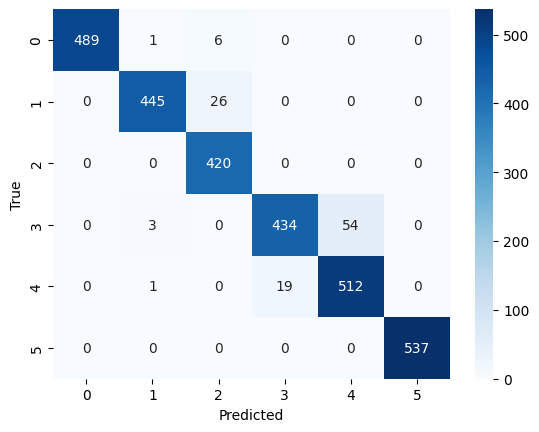

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure()
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()